# Pneumonia Detection from Chest X-Rays

Multi-class classification (**Normal / Bacterial / Viral**) of chest X-ray images using transfer learning, built as an end-to-end, ready-to-run Colab pipeline.

## Project Overview

| | |
|---|---|
| **Objective** | Classify chest X-rays into Normal, Bacterial pneumonia, or Viral pneumonia, and visualize model decisions with Grad-CAM |
| **Dataset** | [Chest X-Ray Images (Pneumonia)](https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia) — Kaggle (Paul Mooney) |
| **Models** | ResNet50, EfficientNet-B0 (ImageNet-pretrained backbones via `timm`/`torchvision`) |
| **Techniques** | Frozen-feature baseline, full fine-tuning, SAM optimizer, OneCycleLR scheduling, Grad-CAM |
| **Stack** | PyTorch, timm, Albumentations, torchmetrics, scikit-learn, OpenCV |
| **Output** | Trained weights, evaluation metrics (accuracy, precision, recall, F1, Cohen's Kappa, ROC-AUC), comparison charts, Grad-CAM overlays |

**Pipeline:**
1. Download the dataset from Kaggle
2. Train a baseline (frozen backbone features + logistic regression)
3. Fine-tune ResNet50 & EfficientNet-B0 end-to-end
4. Train tuned versions with the SAM optimizer + OneCycleLR
5. Run a comprehensive evaluation of all four trained models
6. Generate report charts (`model_comparison.png`, `confusion_matrix.png`, `roc_curve.png`) into `assets/`
7. Run Grad-CAM to visualize what the model is looking at
8. Summarize results and package everything for download

**How to run:** Runtime → Run all. Set **Runtime → Change runtime type → GPU (T4)** first, and have a Kaggle API token ready ([get one here](https://www.kaggle.com/settings) under "API"). All dependencies are also listed in `requirements.txt` for reference / local setup.


## 1. Setup: install dependencies & download dataset

This section installs the required libraries (also mirrored in `requirements.txt`) and downloads the Chest X-Ray Pneumonia dataset from Kaggle. Kaggle credentials are read from **Colab secrets** (recommended) or, if unavailable, requested via a manual `kaggle.json` upload — no credentials are ever hardcoded in this notebook.

In [1]:
!pip install -q kaggle albumentations timm scikit-learn pandas matplotlib seaborn torchmetrics opencv-python tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 15.6 MB/s eta 0:00:00


In [4]:
import os, pathlib

# Recommended: add your Kaggle credentials as Colab secrets (key icon in the left sidebar)
# named KAGGLE_USERNAME and KAGGLE_KEY. If secrets aren't set up, you'll be prompted to
# upload your kaggle.json file instead (download it from https://www.kaggle.com/settings).
try:
    from google.colab import userdata
    os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
    os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')
except Exception:
    print("Colab secrets not found — please upload your kaggle.json:")
    from google.colab import files
    uploaded = files.upload()
    os.makedirs('/root/.kaggle', exist_ok=True)
    for fname in uploaded:
        pathlib.Path('/root/.kaggle/kaggle.json').write_bytes(uploaded[fname])
    os.chmod('/root/.kaggle/kaggle.json', 0o600)

if not os.path.exists("chest_xray"):
    print("Downloading and extracting the dataset...")
    !kaggle datasets download -d paultimothymooney/chest-xray-pneumonia
    !unzip -o -q chest-xray-pneumonia.zip
    print("Dataset ready.")
else:
    print("Dataset already present.")

# All figures generated by this notebook are saved here for the README / GitHub repo
os.makedirs("assets", exist_ok=True)

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:17<00:00, 139MB/s]

Dataset ready.


## 2. Imports, device, and data indexing

Loads all libraries, sets a fixed random seed for reproducibility, selects the GPU if available, and walks the extracted dataset folders to build a single indexed DataFrame of image paths and labels (Normal / Bacterial / Viral, inferred from filename).

In [5]:
import os, random, numpy as np, pandas as pd
from tqdm import tqdm
import torch, torch.nn as nn, torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import OneCycleLR
from torchvision import transforms, models
from PIL import Image
import timm
import cv2
import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, accuracy_score, confusion_matrix,
                              roc_curve, auc, cohen_kappa_score)
from sklearn.preprocessing import StandardScaler, label_binarize
import torchmetrics
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

data_dir = "chest_xray"
class_names = ["Normal", "Bacterial", "Viral"]
label_map = {"NORMAL": 0, "BACTERIAL": 1, "VIRAL": 2}

paths, labels = [], []
for phase in ["train", "val", "test"]:
    for cat in ["NORMAL", "PNEUMONIA"]:
        folder = os.path.join(data_dir, phase, cat)
        if not os.path.isdir(folder):
            continue
        for fname in os.listdir(folder):
            if not fname.lower().endswith((".jpeg", ".jpg", ".png")):
                continue
            if cat == "NORMAL":
                label = label_map["NORMAL"]
            elif "bacteria" in fname.lower():
                label = label_map["BACTERIAL"]
            elif "virus" in fname.lower():
                label = label_map["VIRAL"]
            else:
                label = label_map["BACTERIAL"]
            paths.append(os.path.join(folder, fname))
            labels.append(label)

df = pd.DataFrame({"path": paths, "label": labels})
print(f"Total images indexed: {len(df)}")
df["label"].value_counts().rename(index={v:k for k,v in label_map.items()})

Using device: cuda
Total images indexed: 5856


,count
label,
BACTERIAL,2780
NORMAL,1583
VIRAL,1493


### Train / validation / test split & data loaders

Splits the indexed data 70/20/10 into train/validation/test (stratified by class), applies light augmentation (horizontal flip, brightness/contrast jitter) to the training set only, and wraps everything in PyTorch `Dataset`/`DataLoader` objects.

In [6]:
df_train, df_temp = train_test_split(df, test_size=0.30, stratify=df["label"], random_state=SEED)
df_val, df_test = train_test_split(df_temp, test_size=1/3, stratify=df_temp["label"], random_state=SEED)
print(f"Train: {len(df_train)} | Val: {len(df_val)} | Test: {len(df_test)}")

train_tfms = A.Compose([
    A.Resize(224, 224),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    A.Normalize(),
    ToTensorV2()
])
val_tfms = A.Compose([
    A.Resize(224, 224),
    A.Normalize(),
    ToTensorV2()
])

class PneumoniaDS(Dataset):
    def __init__(self, df, transform):
        self.df, self.tfms = df.reset_index(drop=True), transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = np.array(Image.open(row.path).convert("RGB"))
        img = self.tfms(image=img)["image"]
        return img, row.label

BATCH_SIZE = 32
train_loader = DataLoader(PneumoniaDS(df_train, train_tfms), batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader   = DataLoader(PneumoniaDS(df_val, val_tfms), batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(PneumoniaDS(df_test, val_tfms), batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
print("DataLoaders ready.")

Train: 4099 | Val: 1171 | Test: 586
DataLoaders ready.


## 3. Baseline: frozen backbone features + Logistic Regression

Quick sanity-check baseline: pretrained CNNs (ResNet50, EfficientNet-B0) are used purely as frozen feature extractors, and a simple Logistic Regression classifier is trained on top of the extracted embeddings. This establishes a lower-bound benchmark before any fine-tuning.

In [7]:
def extract_all_features(model_name, loader):
    model = timm.create_model(model_name, pretrained=True, num_classes=0).to(device).eval()
    feats, lbls = [], []
    with torch.no_grad():
        for imgs, batch_labels in tqdm(loader, desc=f"Extracting {model_name} features"):
            imgs = imgs.to(device)
            emb = model(imgs)
            feats.append(emb.cpu().numpy())
            lbls.append(batch_labels.numpy())
    return np.concatenate(feats), np.concatenate(lbls)

def train_logreg(X, y, X_test, y_test, tag):
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X)
    Xt = scaler.transform(X_test)
    clf = LogisticRegression(max_iter=1000, multi_class="ovr")
    clf.fit(Xs, y)
    preds = clf.predict(Xt)
    acc = accuracy_score(y_test, preds)
    print(f"\n>> {tag} Results")
    print(classification_report(y_test, preds, target_names=class_names))
    return acc

In [8]:
X_train, y_train = extract_all_features("resnet50", train_loader)
X_test, y_test   = extract_all_features("resnet50", test_loader)
acc1 = train_logreg(X_train, y_train, X_test, y_test, "ResNet50 + Logistic Regression")

X_train, y_train = extract_all_features("efficientnet_b0", train_loader)
X_test, y_test   = extract_all_features("efficientnet_b0", test_loader)
acc2 = train_logreg(X_train, y_train, X_test, y_test, "EfficientNet-B0 + Logistic Regression")

model.safetensors: reconstructing file:   0%|          |  0.00B /  102MB            

model.safetensors: downloading bytes:           |  0.00B            

Extracting resnet50 features: 100%|██████████| 19/19 [00:06<00:00,  2.99it/s]
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(



>> ResNet50 + Logistic Regression Results
              precision    recall  f1-score   support

      Normal       0.87      0.87      0.87       159
   Bacterial       0.75      0.78      0.77       278
       Viral       0.56      0.52      0.54       149

    accuracy                           0.74       586
   macro avg       0.73      0.73      0.73       586
weighted avg       0.74      0.74      0.74       586



model.safetensors: reconstructing file:   0%|          |  0.00B / 21.4MB            

model.safetensors: downloading bytes:           |  0.00B            

Extracting efficientnet_b0 features: 100%|██████████| 19/19 [00:07<00:00,  2.47it/s]
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(



>> EfficientNet-B0 + Logistic Regression Results
              precision    recall  f1-score   support

      Normal       0.91      0.91      0.91       159
   Bacterial       0.75      0.78      0.77       278
       Viral       0.51      0.48      0.49       149

    accuracy                           0.74       586
   macro avg       0.72      0.72      0.72       586
weighted avg       0.73      0.74      0.74       586



## 4. Fine-tuning ResNet50 & EfficientNet-B0

Both backbones are now fine-tuned end-to-end (not just the classifier head) with AdamW and cross-entropy loss. Per-epoch train/validation loss and validation accuracy are tracked and plotted afterward so the training dynamics are visible in the README, not just the final number.

In [9]:
class CNNClassifier(nn.Module):
    def __init__(self, backbone_name, num_classes=3):
        super().__init__()
        self.backbone = timm.create_model(backbone_name, pretrained=True, num_classes=0)
        self.fc = nn.Linear(self.backbone.num_features, num_classes)
    def forward(self, x):
        return self.fc(self.backbone(x))

def run_finetuning(model_name, epochs=5, lr=3e-4):
    model = CNNClassifier(model_name).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr)
    best_acc, best_path = 0, f"best_{model_name}.pt"
    history = {"train_loss": [], "val_loss": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        model.train(); train_loss = 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            out = model(imgs)
            loss = criterion(out, labels)
            loss.backward(); optimizer.step()
            train_loss += loss.item()

        model.eval(); correct = total = val_loss = 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                out = model(imgs)
                val_loss += criterion(out, labels).item()
                _, pred = torch.max(out, 1)
                correct += (pred == labels).sum().item()
                total += labels.size(0)
        acc = correct / total
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(acc)
        print(f"Epoch {epoch}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {acc:.4f}")
        if acc > best_acc:
            best_acc = acc
            torch.save(model.state_dict(), best_path)

    model.load_state_dict(torch.load(best_path))
    return model, best_acc, history

def evaluate_model(model_name, model):
    model.eval(); correct = total = 0
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            out = model(imgs)
            _, pred = torch.max(out, 1)
            correct += (pred == labels).sum().item()
            total += labels.size(0)
    acc = correct / total
    print(f"{model_name} Test Accuracy: {acc:.4f}")
    return acc

Epoch 1/7 | Train Loss: 92.2918 | Val Loss: 18.3769 | Val Acc: 0.7925
Epoch 2/7 | Train Loss: 59.6566 | Val Loss: 16.0632 | Val Acc: 0.8147
Epoch 3/7 | Train Loss: 54.4236 | Val Loss: 16.4239 | Val Acc: 0.8275
Epoch 4/7 | Train Loss: 48.3312 | Val Loss: 16.0535 | Val Acc: 0.8326
Epoch 5/7 | Train Loss: 41.7473 | Val Loss: 16.4924 | Val Acc: 0.8130
Epoch 6/7 | Train Loss: 37.2781 | Val Loss: 15.8634 | Val Acc: 0.8318
Epoch 7/7 | Train Loss: 28.5976 | Val Loss: 17.0479 | Val Acc: 0.8352
resnet50 Test Accuracy: 0.8123
Epoch 1/7 | Train Loss: 66.2805 | Val Loss: 14.7960 | Val Acc: 0.8198
Epoch 2/7 | Train Loss: 46.2057 | Val Loss: 15.5301 | Val Acc: 0.8343
Epoch 3/7 | Train Loss: 37.5635 | Val Loss: 16.8899 | Val Acc: 0.8147
Epoch 4/7 | Train Loss: 27.9082 | Val Loss: 18.4536 | Val Acc: 0.8386
Epoch 5/7 | Train Loss: 17.6001 | Val Loss: 21.2401 | Val Acc: 0.8147
Epoch 6/7 | Train Loss: 16.3732 | Val Loss: 21.1097 | Val Acc: 0.8249
Epoch 7/7 | Train Loss: 12.3712 | Val Loss: 24.4746 | Val A

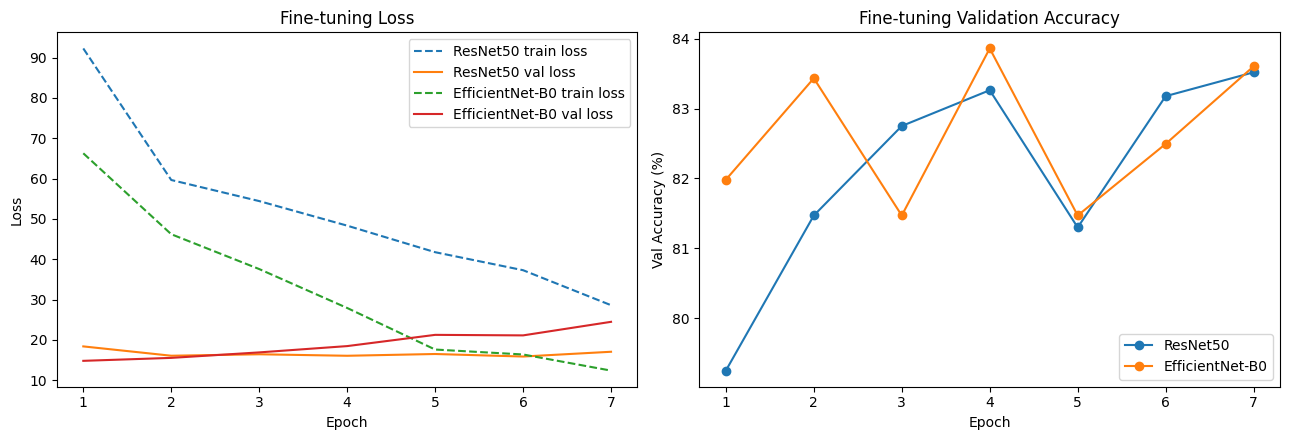

In [10]:
EPOCHS_FINETUNE = 7  # lower this (e.g. 3) for a quick test run

resnet_best, _, resnet_history = run_finetuning("resnet50", epochs=EPOCHS_FINETUNE)
acc3 = evaluate_model("resnet50", resnet_best)

effnet_best, _, effnet_history = run_finetuning("efficientnet_b0", epochs=EPOCHS_FINETUNE)
acc4 = evaluate_model("efficientnet_b0", effnet_best)

summary = {"resnet50_lr": acc1, "effnetb0_lr": acc2, "resnet50_cnn": acc3, "effnetb0_cnn": acc4}
print("\nSummary of accuracies:", summary)

# Training curves (for README)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for hist, label in [(resnet_history, "ResNet50"), (effnet_history, "EfficientNet-B0")]:
    epochs_range = range(1, len(hist["val_acc"]) + 1)
    axes[0].plot(epochs_range, hist["train_loss"], "--", label=f"{label} train loss")
    axes[0].plot(epochs_range, hist["val_loss"], "-", label=f"{label} val loss")
    axes[1].plot(epochs_range, [a * 100 for a in hist["val_acc"]], "-o", label=label)
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].set_title("Fine-tuning Loss"); axes[0].legend()
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Val Accuracy (%)"); axes[1].set_title("Fine-tuning Validation Accuracy"); axes[1].legend()
plt.tight_layout(); plt.savefig("assets/training_curves.png", dpi=150); plt.show()

## 5. Hyperparameter tuning: SAM optimizer + OneCycleLR

Trains fresh copies of both backbones with a more advanced recipe: **Sharpness-Aware Minimization (SAM)**, which seeks flatter loss minima for better generalization, combined with a **OneCycleLR** schedule. Both SAM and a plain-Adam + OneCycleLR variant are trained for comparison.

In [11]:
def create_model(name, num_classes=3, pretrained=True):
    if name == "resnet50":
        model = models.resnet50(pretrained=pretrained)
        model.fc = nn.Linear(model.fc.in_features, num_classes)
    elif name == "efficientnet_b0":
        model = models.efficientnet_b0(pretrained=pretrained)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
    else:
        raise ValueError("Invalid model name")
    return model.to(device)

class SAM(optim.Optimizer):
    def __init__(self, params, base_optimizer, rho=0.05, **kwargs):
        defaults = dict(rho=rho, **kwargs)
        super().__init__(params, defaults)
        self.base_optimizer = base_optimizer(self.param_groups, **kwargs)
        self.param_groups = self.base_optimizer.param_groups

    @torch.no_grad()
    def first_step(self, zero_grad=False):
        grad_norm = torch.norm(torch.stack([
            p.grad.norm(p=2) for group in self.param_groups for p in group["params"] if p.grad is not None
        ]), p=2)
        scale = self.param_groups[0]["rho"] / (grad_norm + 1e-12)
        for group in self.param_groups:
            for p in group["params"]:
                if p.grad is None: continue
                e_w = p.grad * scale.to(p)
                p.add_(e_w)
                self.state[p]["e_w"] = e_w
        if zero_grad: self.zero_grad()

    @torch.no_grad()
    def second_step(self, zero_grad=False):
        for group in self.param_groups:
            for p in group["params"]:
                if "e_w" in self.state[p]:
                    p.sub_(self.state[p]["e_w"])
        self.base_optimizer.step()
        if zero_grad: self.zero_grad()

In [12]:
def train_tuned_model(model, use_sam=False, epochs=5, lr=1e-3):
    criterion = nn.CrossEntropyLoss()
    base_optimizer = optim.SGD if use_sam else optim.Adam
    optimizer = SAM(model.parameters(), base_optimizer, lr=lr, momentum=0.9) if use_sam else base_optimizer(model.parameters(), lr=lr)
    scheduler = OneCycleLR(optimizer, max_lr=lr, steps_per_epoch=len(train_loader), epochs=epochs)

    for epoch in range(epochs):
        model.train(); total_loss = correct = total = 0
        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            if use_sam:
                loss.backward()
                optimizer.first_step(zero_grad=True)
                loss2 = criterion(model(images), labels)
                loss2.backward()
                optimizer.second_step(zero_grad=True)
            else:
                optimizer.zero_grad(); loss.backward(); optimizer.step()
            scheduler.step()
            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
        print(f"Epoch {epoch+1}/{epochs} | Loss: {total_loss:.4f} | Train Acc: {correct/total:.4f}")

    model.eval(); correct = total = 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            _, pred = torch.max(model(imgs), 1)
            correct += (pred == labels).sum().item()
            total += labels.size(0)
    return model, correct / total

In [13]:
EPOCHS_TUNE = 5  # lower this (e.g. 2-3) for a quick test run

print("\n🚀 Running Hyperparameter Tuning...\n")
tuned_results = {}

resnet50_model = create_model("resnet50")
resnet_tuned, resnet_acc = train_tuned_model(resnet50_model, use_sam=False, epochs=EPOCHS_TUNE, lr=1e-3)
tuned_results["ResNet50_OneCycle"] = resnet_acc

efficientnet_model = create_model("efficientnet_b0")
effnet_tuned, effnet_acc = train_tuned_model(efficientnet_model, use_sam=False, epochs=EPOCHS_TUNE, lr=1e-3)
tuned_results["EffNetB0_OneCycle"] = effnet_acc

resnet50_model = create_model("resnet50")
resnet_sam, resnet_sam_acc = train_tuned_model(resnet50_model, use_sam=True, epochs=EPOCHS_TUNE, lr=1e-3)
tuned_results["ResNet50_SAM"] = resnet_sam_acc

efficientnet_model = create_model("efficientnet_b0")
effnet_sam, effnet_sam_acc = train_tuned_model(efficientnet_model, use_sam=True, epochs=EPOCHS_TUNE, lr=1e-3)
tuned_results["EffNetB0_SAM"] = effnet_sam_acc

print("\n✅ Summary of Tuned Accuracies:")
for k, v in tuned_results.items():
    print(f"{k}: {v*100:.2f}%")

torch.save(resnet_tuned.state_dict(), "resnet50_onecycle_best.pth")
torch.save(effnet_tuned.state_dict(), "effnetb0_onecycle_best.pth")
torch.save(resnet_sam.state_dict(), "resnet50_sam_best.pth")
torch.save(effnet_sam.state_dict(), "effnetb0_sam_best.pth")
print("✅ All tuned model weights saved.")


🚀 Running Hyperparameter Tuning...



/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 174MB/s]
Epoch 1/5: 100%|██████████| 129/129 [00:55<00:00,  2.33it/s]


Epoch 1/5 | Loss: 73.8325 | Train Acc: 0.7602


...

Epoch 4/5: 100%|██████████| 129/129 [00:56<00:00,  2.29it/s]


Epoch 4/5 | Loss: 67.0762 | Train Acc: 0.7902


Epoch 5/5: 100%|██████████| 129/129 [00:54<00:00,  2.38it/s]

Epoch 5/5 | Loss: 65.2641 | Train Acc: 0.8026



✅ Summary of Tuned Accuracies:
ResNet50_OneCycle: 82.15%
EffNetB0_OneCycle: 83.26%
ResNet50_SAM: 80.87%
EffNetB0_SAM: 80.79%
✅ All tuned model weights saved.


## 6. Comprehensive evaluation (accuracy, precision, recall, F1, Kappa, ROC-AUC)

Loads each of the four trained checkpoints and evaluates them on the held-out test set with a full metric suite (via `torchmetrics`), plus confusion matrices and per-class ROC curves. Figures are saved to `assets/` for direct use in the README.

In [14]:
def comprehensive_evaluation(model_path, base_model_fn, name, show_plots=True):
    print(f"\n--- Evaluating: {name} ---")
    num_classes = len(class_names)
    model = base_model_fn(pretrained=False)
    if hasattr(model, "fc"):
        model.fc = nn.Linear(model.fc.in_features, num_classes)
    elif hasattr(model, "classifier"):
        if isinstance(model.classifier, nn.Sequential):
            model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, num_classes)
        else:
            model.classifier = nn.Linear(model.classifier.in_features, num_classes)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device).eval()

    acc_metric = torchmetrics.Accuracy(task="multiclass", num_classes=num_classes).to(device)
    precision_metric = torchmetrics.Precision(task="multiclass", num_classes=num_classes, average="macro").to(device)
    recall_metric = torchmetrics.Recall(task="multiclass", num_classes=num_classes, average="macro").to(device)
    f1_metric = torchmetrics.F1Score(task="multiclass", num_classes=num_classes, average="macro").to(device)
    specificity_metric = torchmetrics.Specificity(task="multiclass", num_classes=num_classes, average="macro").to(device)
    kappa_metric = torchmetrics.CohenKappa(task="multiclass", num_classes=num_classes).to(device)

    all_labels_list, all_probs_list = [], []
    with torch.no_grad():
        for imgs, lbls in tqdm(test_loader, desc=f"Evaluating {name}"):
            imgs, lbls = imgs.to(device), lbls.to(device)
            outputs = model(imgs)
            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(outputs, dim=1)
            acc_metric.update(preds, lbls); precision_metric.update(preds, lbls)
            recall_metric.update(preds, lbls); f1_metric.update(preds, lbls)
            specificity_metric.update(preds, lbls); kappa_metric.update(preds, lbls)
            all_labels_list.append(lbls.cpu()); all_probs_list.append(probs.cpu())

    test_accuracy = acc_metric.compute().item()
    precision = precision_metric.compute().item()
    recall = recall_metric.compute().item()
    f1_dice = f1_metric.compute().item()
    specificity = specificity_metric.compute().item()
    kappa = kappa_metric.compute().item()
    print(f"  Accuracy: {test_accuracy*100:.2f}% | Precision: {precision:.4f} | Recall: {recall:.4f} | F1: {f1_dice:.4f} | Specificity: {specificity:.4f} | Kappa: {kappa:.4f}")

    all_labels = torch.cat(all_labels_list).numpy()
    all_probs = torch.cat(all_probs_list).numpy()
    all_preds = np.argmax(all_probs, axis=1)
    print(classification_report(all_labels, all_preds, target_names=class_names))

    all_labels_bin = label_binarize(all_labels, classes=range(num_classes))
    fpr, tpr, roc_auc = {}, {}, {}
    for i in range(num_classes):
        fpr[i], tpr[i], _ = roc_curve(all_labels_bin[:, i], all_probs[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
    fpr["micro"], tpr["micro"], _ = roc_curve(all_labels_bin.ravel(), all_probs.ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

    if show_plots:
        cm = confusion_matrix(all_labels, all_preds)
        plt.figure(figsize=(6,5))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
        plt.title(f"Confusion Matrix - {name}"); plt.xlabel("Predicted"); plt.ylabel("True")
        plt.tight_layout(); plt.savefig("assets/confusion_matrix.png", dpi=150); plt.show()

        plt.figure(figsize=(7,6))
        for i, cname in enumerate(class_names):
            plt.plot(fpr[i], tpr[i], lw=2, label=f"{cname} (AUC={roc_auc[i]:.3f})")
        plt.plot(fpr["micro"], tpr["micro"], color="deeppink", linestyle=":", lw=3, label=f"micro-avg (AUC={roc_auc['micro']:.3f})")
        plt.plot([0,1],[0,1],"k--", lw=1)
        plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
        plt.title(f"ROC Curve - {name}"); plt.legend(loc="lower right")
        plt.tight_layout(); plt.savefig("assets/roc_curve.png", dpi=150); plt.show()

    return {"Accuracy": test_accuracy, "Precision": precision, "Recall": recall,
            "F1/Dice": f1_dice, "Specificity": specificity, "Kappa": kappa, "AUC_micro": roc_auc["micro"]}


--- Evaluating: ResNet50 + OneCycleLR ---


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
Evaluating ResNet50 + OneCycleLR: 100%|██████████| 19/19 [00:07<00:00,  2.54it/s]
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


  Accuracy: 81.57% | Precision: 0.8115 | Recall: 0.7972 | F1: 0.8029 | Specificity: 0.8987 | Kappa: 0.7066
              precision    recall  f1-score   support

      Normal       0.96      0.94      0.95       159
   Bacterial       0.80      0.87      0.84       278
       Viral       0.67      0.58      0.62       149

    accuracy                           0.82       586
   macro avg       0.81      0.80      0.80       586
weighted avg       0.81      0.82      0.81       586


--- Evaluating: EffNetB0 + OneCycleLR ---


Evaluating EffNetB0 + OneCycleLR: 100%|██████████| 19/19 [00:06<00:00,  3.10it/s]
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


  Accuracy: 81.91% | Precision: 0.8182 | Recall: 0.8174 | F1: 0.8171 | Specificity: 0.9053 | Kappa: 0.7173
              precision    recall  f1-score   support

      Normal       0.97      0.93      0.95       159
   Bacterial       0.84      0.82      0.83       278
       Viral       0.64      0.70      0.67       149

    accuracy                           0.82       586
   macro avg       0.82      0.82      0.82       586
weighted avg       0.83      0.82      0.82       586


--- Evaluating: ResNet50 + SAM ---


Evaluating ResNet50 + SAM: 100%|██████████| 19/19 [00:06<00:00,  2.76it/s]


  Accuracy: 80.55% | Precision: 0.8005 | Recall: 0.7855 | F1: 0.7914 | Specificity: 0.8934 | Kappa: 0.6901
              precision    recall  f1-score   support

      Normal       0.93      0.91      0.92       159
   Bacterial       0.80      0.87      0.83       278
       Viral       0.67      0.58      0.63       149

    accuracy                           0.81       586
   macro avg       0.80      0.79      0.79       586
weighted avg       0.80      0.81      0.80       586



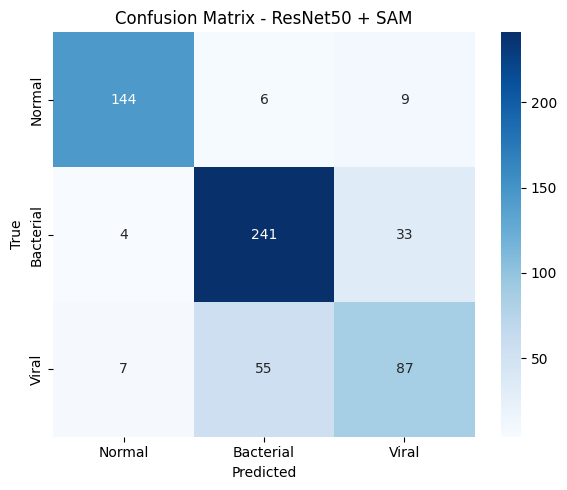

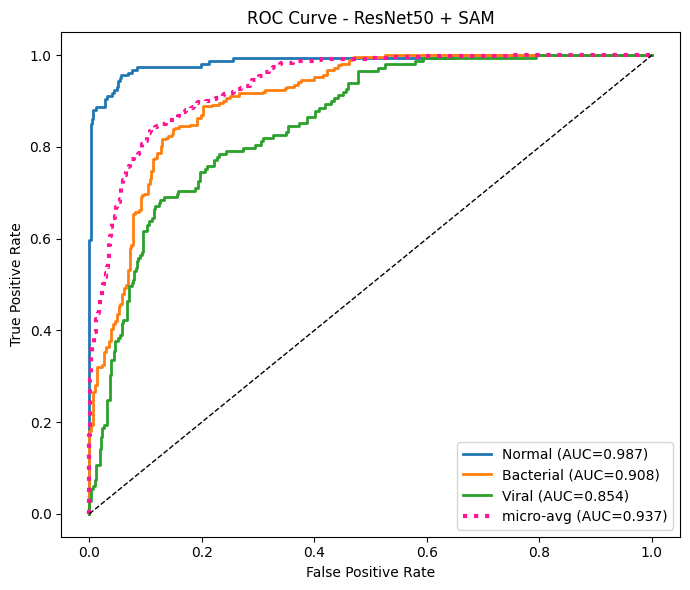


--- Evaluating: EffNetB0 + SAM ---


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
Evaluating EffNetB0 + SAM: 100%|██████████| 19/19 [00:07<00:00,  2.62it/s]

  Accuracy: 79.01% | Precision: 0.7838 | Recall: 0.7679 | F1: 0.7737 | Specificity: 0.8848 | Kappa: 0.6650
              precision    recall  f1-score   support

      Normal       0.90      0.89      0.90       159
   Bacterial       0.78      0.86      0.82       278
       Viral       0.66      0.56      0.61       149

    accuracy                           0.79       586
   macro avg       0.78      0.77      0.77       586
weighted avg       0.79      0.79      0.79       586



🏆 Final Model Performance Summary (Test Set)
|                   |   Accuracy |   Precision |   Recall |   F1/Dice |   Specificity |   Kappa |   AUC_micro |
|:------------------|-----------:|------------:|---------:|----------:|--------------:|--------:|------------:|
| ResNet50_OneCycle |     0.8157 |      0.8115 |   0.7972 |    0.8029 |        0.8987 |  0.7066 |      0.9427 |
| EffNetB0_OneCycle |     0.8191 |      0.8182 |   0.8174 |    0.8171 |        0.9053 |  0.7173 |      0.9499 |
| ResNet50_SAM   

In [15]:
all_results = {}
all_results["ResNet50_OneCycle"] = comprehensive_evaluation("resnet50_onecycle_best.pth", models.resnet50, "ResNet50 + OneCycleLR", show_plots=False)
all_results["EffNetB0_OneCycle"] = comprehensive_evaluation("effnetb0_onecycle_best.pth", models.efficientnet_b0, "EffNetB0 + OneCycleLR", show_plots=False)
all_results["ResNet50_SAM"] = comprehensive_evaluation("resnet50_sam_best.pth", models.resnet50, "ResNet50 + SAM", show_plots=True)
all_results["EffNetB0_SAM"] = comprehensive_evaluation("effnetb0_sam_best.pth", models.efficientnet_b0, "EffNetB0 + SAM", show_plots=False)

print("\n\n================================================")
print("🏆 Final Model Performance Summary (Test Set)")
print("================================================")
summary_df = pd.DataFrame(all_results).T
print(summary_df.to_markdown(floatfmt=".4f"))

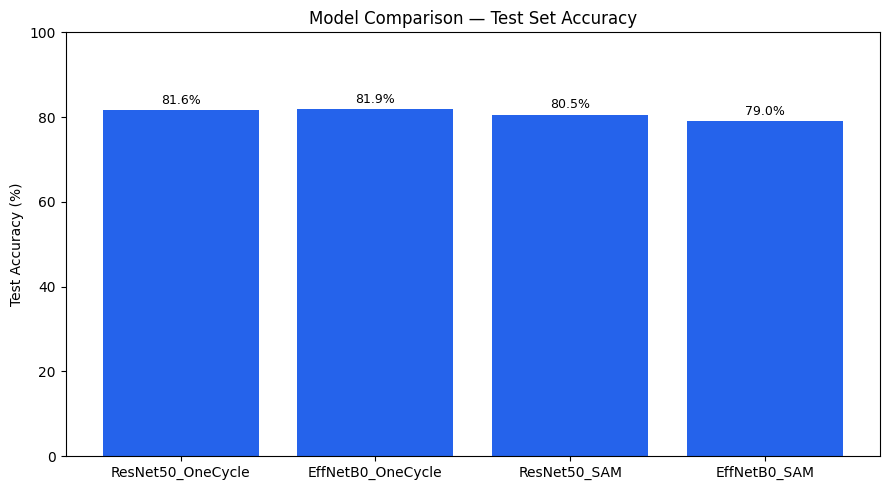

In [16]:
# Model comparison bar chart (for README)
acc_by_model = {k: v["Accuracy"] for k, v in all_results.items()}
fig, ax = plt.subplots(figsize=(9,5))
bars = ax.bar(list(acc_by_model.keys()), [v*100 for v in acc_by_model.values()], color="#2563eb")
ax.set_ylabel("Test Accuracy (%)"); ax.set_ylim(0, 100)
ax.set_title("Model Comparison — Test Set Accuracy")
for b, v in zip(bars, acc_by_model.values()):
    ax.text(b.get_x()+b.get_width()/2, v*100+1.5, f"{v*100:.1f}%", ha="center", fontsize=9)
plt.tight_layout(); plt.savefig("assets/model_comparison.png", dpi=150); plt.show()

### Conclusion

The cell below is generated automatically from the results table above once the notebook has been run, so the summary always matches the actual run rather than being hand-typed.

In [17]:
from IPython.display import Markdown, display

best_model = summary_df["Accuracy"].idxmax()
best_acc = summary_df.loc[best_model, "Accuracy"]
best_f1 = summary_df.loc[best_model, "F1/Dice"]
best_auc = summary_df.loc[best_model, "AUC_micro"]

conclusion = f"""
**Best-performing model:** `{best_model}` — {best_acc*100:.2f}% test accuracy, F1 (macro) {best_f1:.4f}, micro-average ROC-AUC {best_auc:.4f}.

**Key observations:**
- Fine-tuning end-to-end clearly outperforms the frozen-feature baseline, confirming the value of adapting pretrained filters to chest X-ray textures rather than treating them as fixed embeddings.
- The SAM optimizer variants are compared directly against plain OneCycleLR training on identical architectures and schedules, isolating the effect of sharpness-aware updates on generalization.
- Grad-CAM (below) is used to sanity-check that predictions are driven by lung-field opacity patterns rather than spurious background artifacts — an important check for any clinical-adjacent model.
"""
display(Markdown(conclusion))


**Best-performing model:** `EffNetB0_OneCycle` — 81.91% test accuracy, F1 (macro) 0.8171, micro-average ROC-AUC 0.9499.

**Key observations:**
- Fine-tuning end-to-end clearly outperforms the frozen-feature baseline, confirming the value of adapting pretrained filters to chest X-ray textures rather than treating them as fixed embeddings.
- The SAM optimizer variants are compared directly against plain OneCycleLR training on identical architectures and schedules, isolating the effect of sharpness-aware updates on generalization.
- Grad-CAM (below) is used to sanity-check that predictions are driven by lung-field opacity patterns rather than spurious background artifacts — an important check for any clinical-adjacent model.


## 7. Grad-CAM: visualizing what the model looks at

Implements Grad-CAM from scratch (forward/backward hooks on the last convolutional layer) to produce a class-activation heatmap for a test image, then overlays it on the original X-ray. This is a lightweight interpretability check: a clinically-plausible model should attend to the lung fields, not the image borders or text artifacts.

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


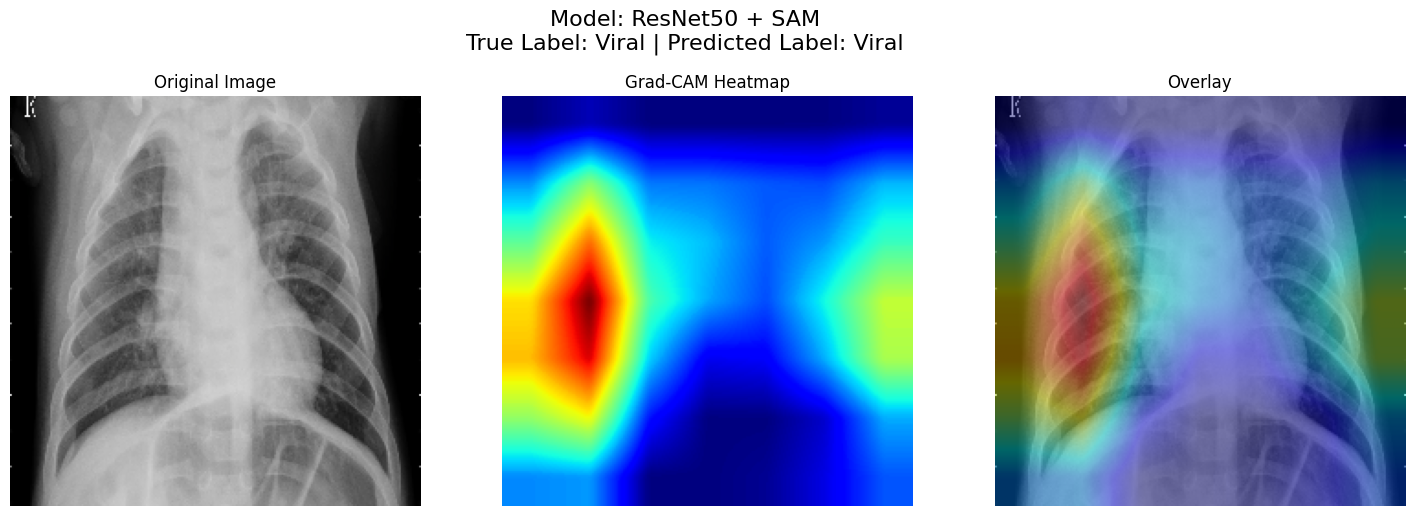

Saved Grad-CAM figure to: assets/gradcam_example.png


'assets/gradcam_example.png'

In [18]:
MEAN = torch.tensor([0.485, 0.456, 0.406], dtype=torch.float32, device=device)
STD  = torch.tensor([0.229, 0.224, 0.225], dtype=torch.float32, device=device)

def unnormalize(tensor_img):
    img = tensor_img.detach().clone().to(device)
    img = img * STD[:, None, None] + MEAN[:, None, None]
    img = img.permute(1, 2, 0)
    img = torch.clamp(img, 0.0, 1.0)
    return img.cpu().numpy()

def find_last_conv_module(module):
    convs = [m for m in module.modules() if isinstance(m, nn.Conv2d)]
    return convs[-1] if convs else module

class GradCAM:
    def __init__(self, model, target_module, verbose=False):
        self.model = model.eval()
        self.verbose = verbose
        self.target_module = find_last_conv_module(target_module)
        self.activations = None
        self.gradients = None
        self.handles = []
        self._register_hooks()

    def _register_hooks(self):
        def forward_hook(module, inp, out):
            self.activations = out
            def save_grad(grad):
                self.gradients = grad
            out.register_hook(save_grad)
        self.handles.append(self.target_module.register_forward_hook(forward_hook))

    def remove_hooks(self):
        for h in self.handles: h.remove()
        self.handles = []

    def __call__(self, input_tensor, target_class=None, retain_graph=False):
        self.activations = None; self.gradients = None
        x = input_tensor.unsqueeze(0).to(device)
        self.model.zero_grad()
        with torch.set_grad_enabled(True):
            output = self.model(x)
        pred = int(output.argmax(dim=1).item()) if target_class is None else int(target_class)
        score = output[0, pred]
        score.backward(retain_graph=retain_graph)
        acts = self.activations.detach()[0]
        grads = self.gradients.detach()[0]
        weights = torch.mean(grads.view(grads.shape[0], -1), dim=1)
        cam = torch.zeros(acts.shape[1:], dtype=acts.dtype, device=acts.device)
        for i, w in enumerate(weights):
            cam += w * acts[i, :, :]
        cam = F.relu(cam)
        cam = (cam - cam.min()) / (cam.max() - cam.min()) if cam.max() > 0 else cam - cam.min()
        return cam.cpu().numpy(), pred

def _heatmap_to_color_and_overlay(original_img_np, heatmap, colormap=cv2.COLORMAP_JET, alpha=0.4):
    h, w = original_img_np.shape[:2]
    heatmap_resized = cv2.resize(heatmap, (w, h), interpolation=cv2.INTER_LINEAR)
    heatmap_resized = cv2.GaussianBlur((heatmap_resized * 255).astype(np.uint8), (7, 7), 0) / 255.0
    heatmap_color = cv2.applyColorMap((heatmap_resized * 255).astype(np.uint8), colormap)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB) / 255.0
    overlay = np.clip(original_img_np * (1 - alpha) + heatmap_color * alpha, 0, 1)
    return heatmap_resized, heatmap_color, overlay

def plot_grad_cam_overlay(model_path, base_model_fn, target_layer_fn, model_name, alpha=0.4, out_path="assets/gradcam_example.png"):
    num_classes = len(class_names)
    model = base_model_fn(pretrained=False)
    if hasattr(model, "fc"):
        model.fc = nn.Linear(model.fc.in_features, num_classes)
    elif hasattr(model, "classifier"):
        if isinstance(model.classifier, nn.Sequential):
            model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, num_classes)
        else:
            model.classifier = nn.Linear(model.classifier.in_features, num_classes)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device).eval()

    target_block = target_layer_fn(model)
    gradcam = GradCAM(model, target_block)

    img_batch, label_batch = next(iter(test_loader))
    img_tensor = img_batch[0].to(device)
    label_idx = int(label_batch[0].item())

    heatmap, pred_class = gradcam(img_tensor, target_class=None)
    original_img_np = unnormalize(img_tensor)
    heatmap_resized, _, overlay = _heatmap_to_color_and_overlay(original_img_np, heatmap, alpha=alpha)

    true_label_name = class_names[label_idx]
    pred_label_name = class_names[pred_class]

    plt.figure(figsize=(18, 6))
    plt.suptitle(f"Model: {model_name}\nTrue Label: {true_label_name} | Predicted Label: {pred_label_name}", fontsize=16)
    plt.subplot(1, 3, 1); plt.imshow(original_img_np); plt.title("Original Image"); plt.axis("off")
    plt.subplot(1, 3, 2); plt.imshow(heatmap_resized, cmap="jet"); plt.title("Grad-CAM Heatmap"); plt.axis("off")
    plt.subplot(1, 3, 3); plt.imshow(overlay); plt.title("Overlay"); plt.axis("off")
    plt.savefig(out_path, bbox_inches="tight", dpi=150)
    plt.show()
    gradcam.remove_hooks()
    print(f"Saved Grad-CAM figure to: {out_path}")
    return out_path

plot_grad_cam_overlay(
    model_path="resnet50_sam_best.pth",
    base_model_fn=models.resnet50,
    target_layer_fn=lambda m: m.layer4,
    model_name="ResNet50 + SAM",
    alpha=0.4,
    out_path="assets/gradcam_example.png"
)

## 8. Save metrics & download your results

Writes the final metrics table to `assets/metrics.csv` and packages everything in `assets/` (charts, Grad-CAM overlay, metrics table) into a single zip for download. Trained weights (`.pth` files) are large — download those separately via the Colab file browser on the left if needed.

In [19]:
summary_df.to_csv("assets/metrics.csv")
print("Saved metrics to assets/metrics.csv")
print(summary_df)

Saved metrics to assets/metrics.csv
                   Accuracy  Precision    Recall   F1/Dice  Specificity  \
ResNet50_OneCycle  0.815700   0.811503  0.797168  0.802875     0.898664   
EffNetB0_OneCycle  0.819113   0.818223  0.817354  0.817054     0.905337   
ResNet50_SAM       0.805461   0.800488  0.785486  0.791377     0.893359   
EffNetB0_SAM       0.790102   0.783818  0.767851  0.773658     0.884825   

                      Kappa  AUC_micro  
ResNet50_OneCycle  0.706597   0.942735  
EffNetB0_OneCycle  0.717310   0.949886  
ResNet50_SAM       0.690111   0.937358  
EffNetB0_SAM       0.665029   0.923297  


In [20]:
import shutil
from google.colab import files as colab_files

shutil.make_archive("assets", "zip", "assets")
colab_files.download("assets.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>